# Explainability and operational audit

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
from src.data_loader import load_partition, predictors, fingerprints
def report(name):
    display(Markdown((ROOT / 'reports' / name).read_text(encoding='utf-8')))
def figure(name):
    display(Image(filename=str(ROOT / 'figures' / name)))


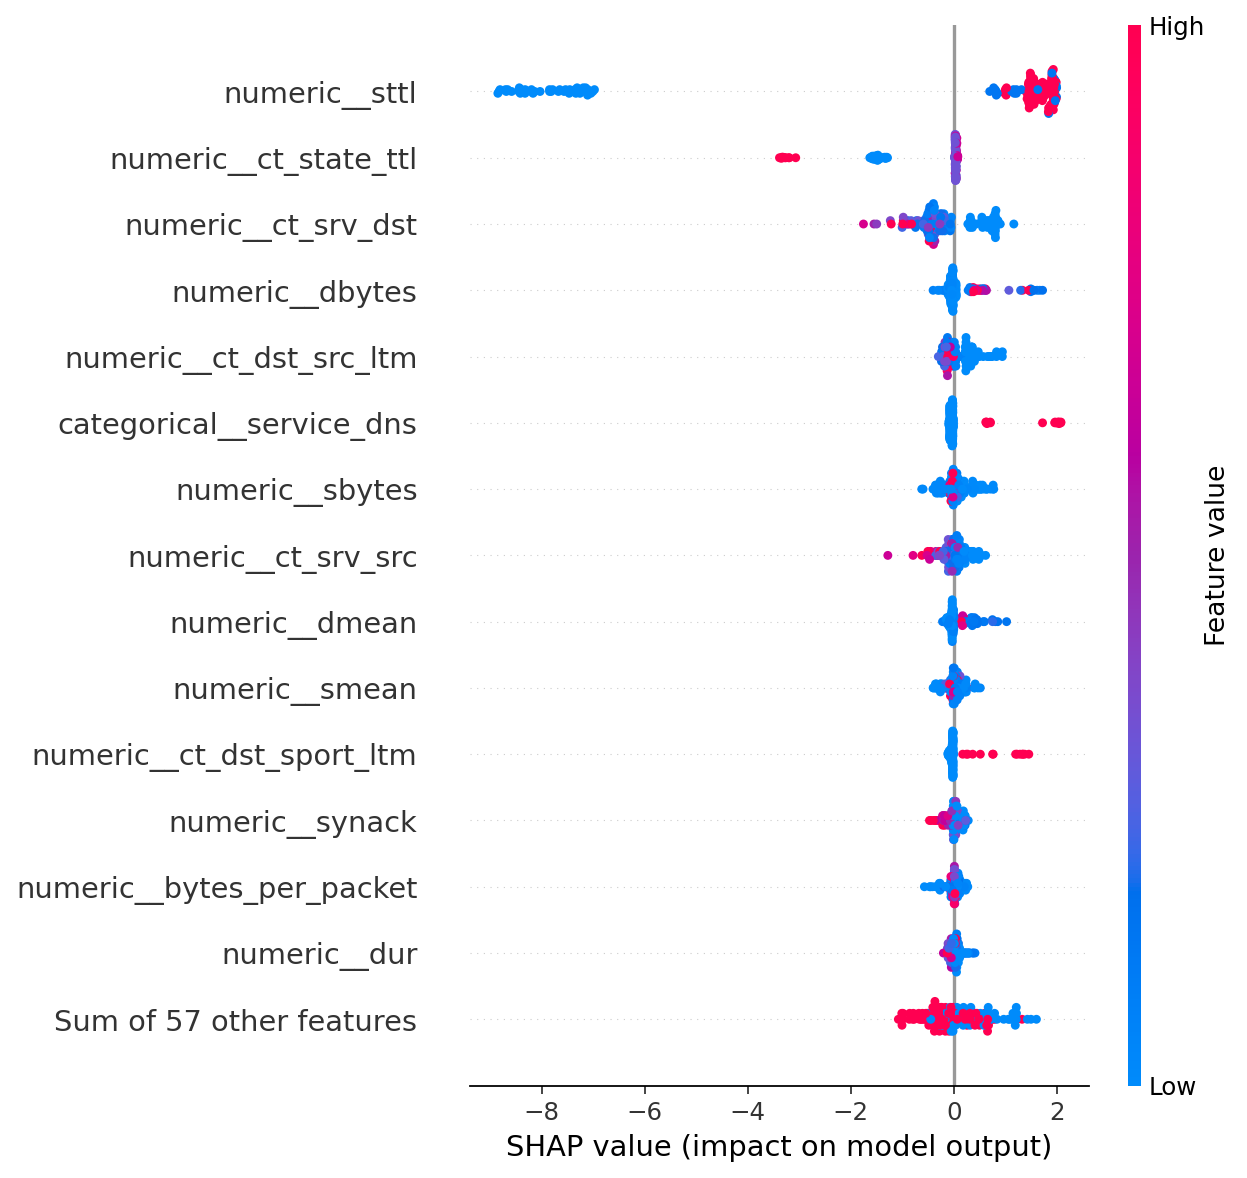

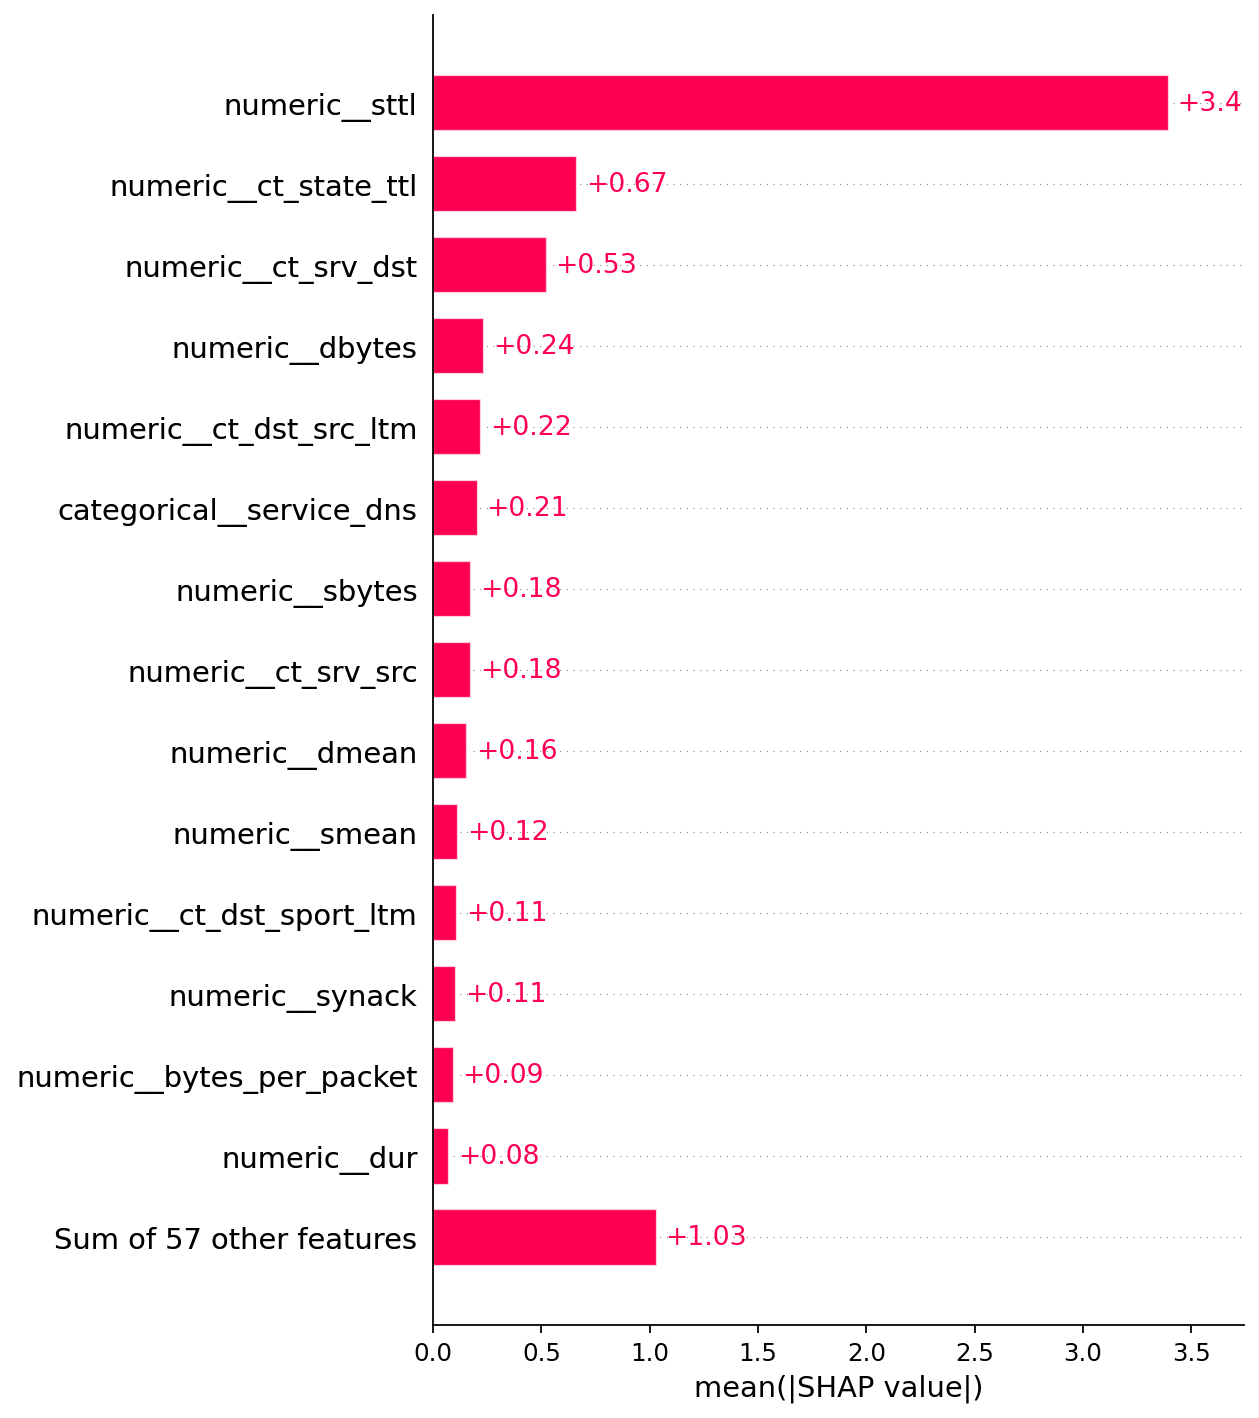

In [2]:
figure('shap_beeswarm.png')
figure('shap_importance.png')

Interpretation: the beeswarm shows signed associations in the fitted tree model; the bar chart shows magnitude. TTL/context reliance may encode collection conditions. SHAP does not establish causality or demographic fairness.

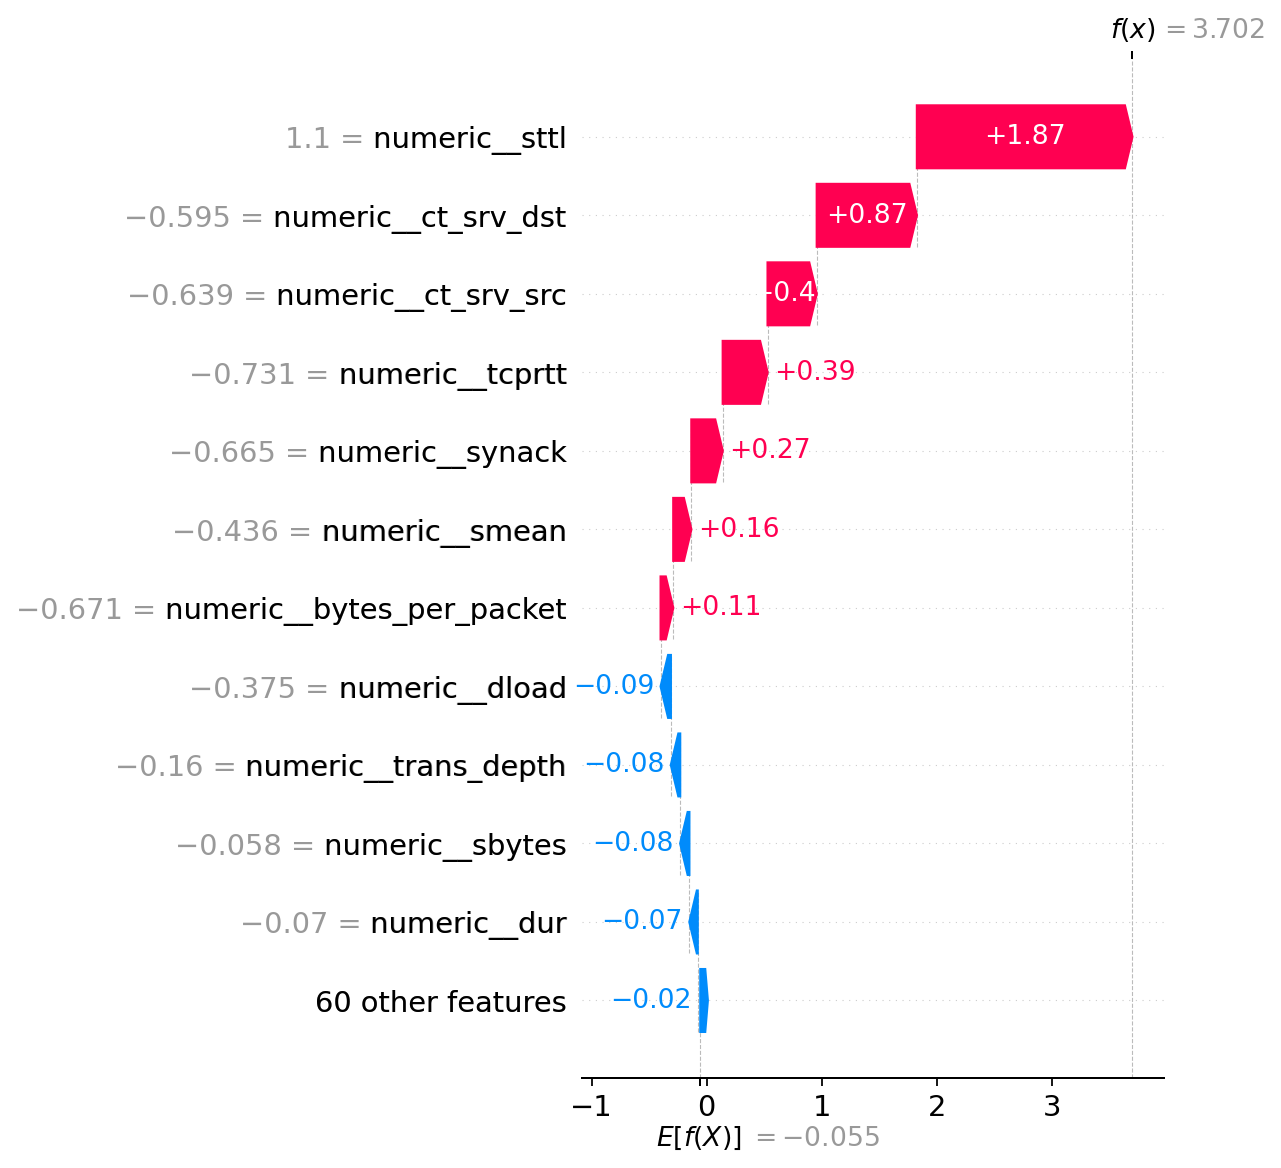

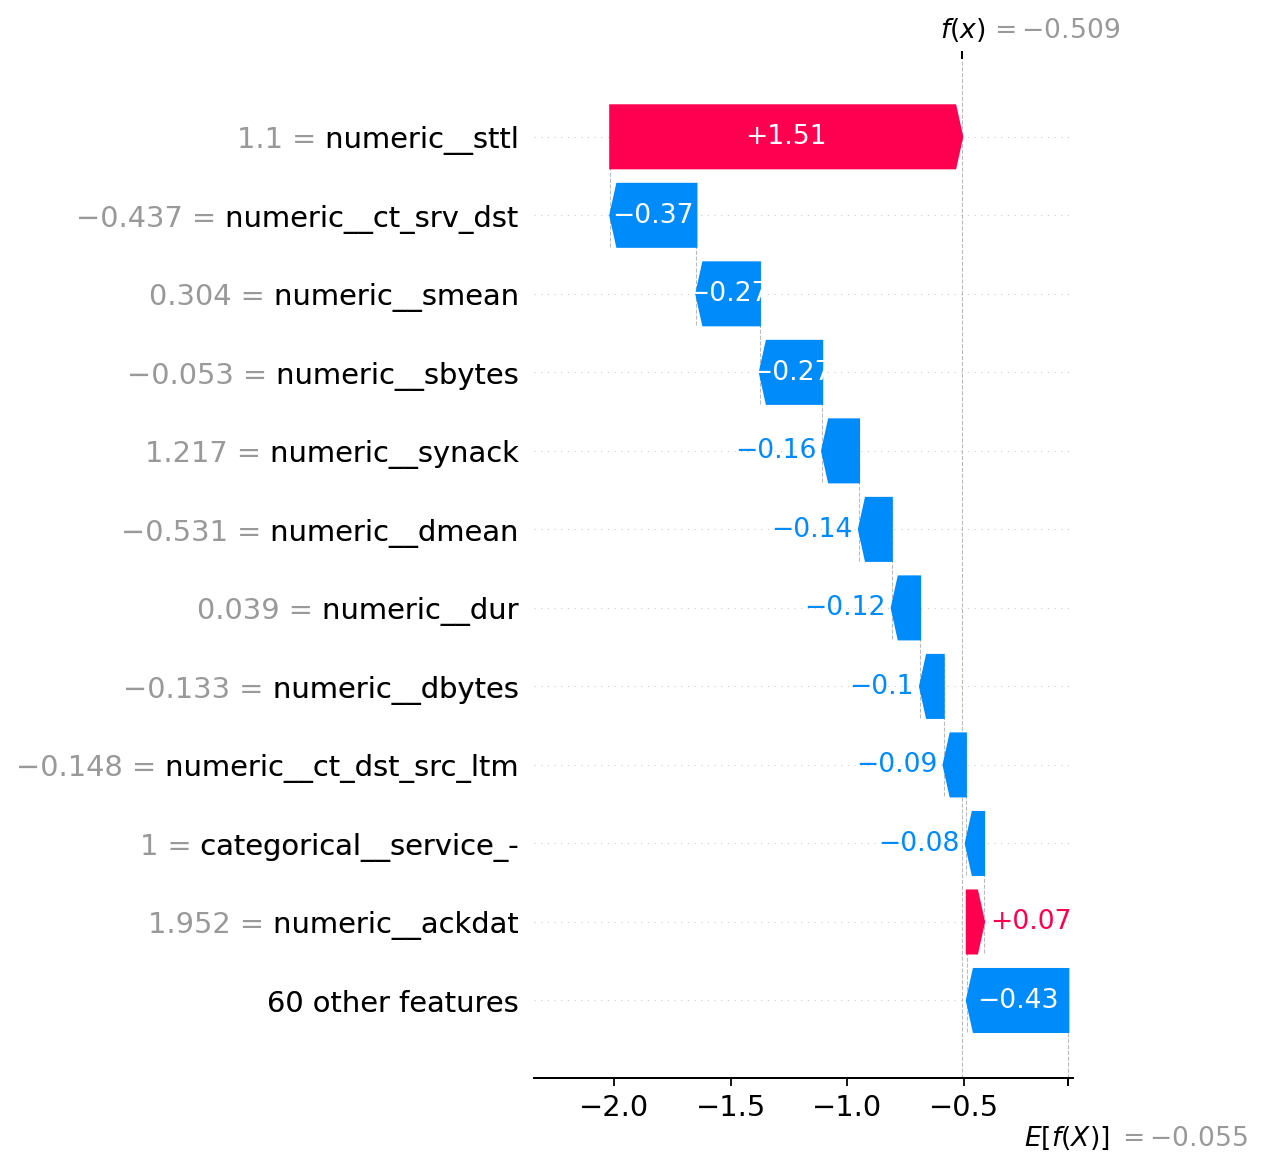

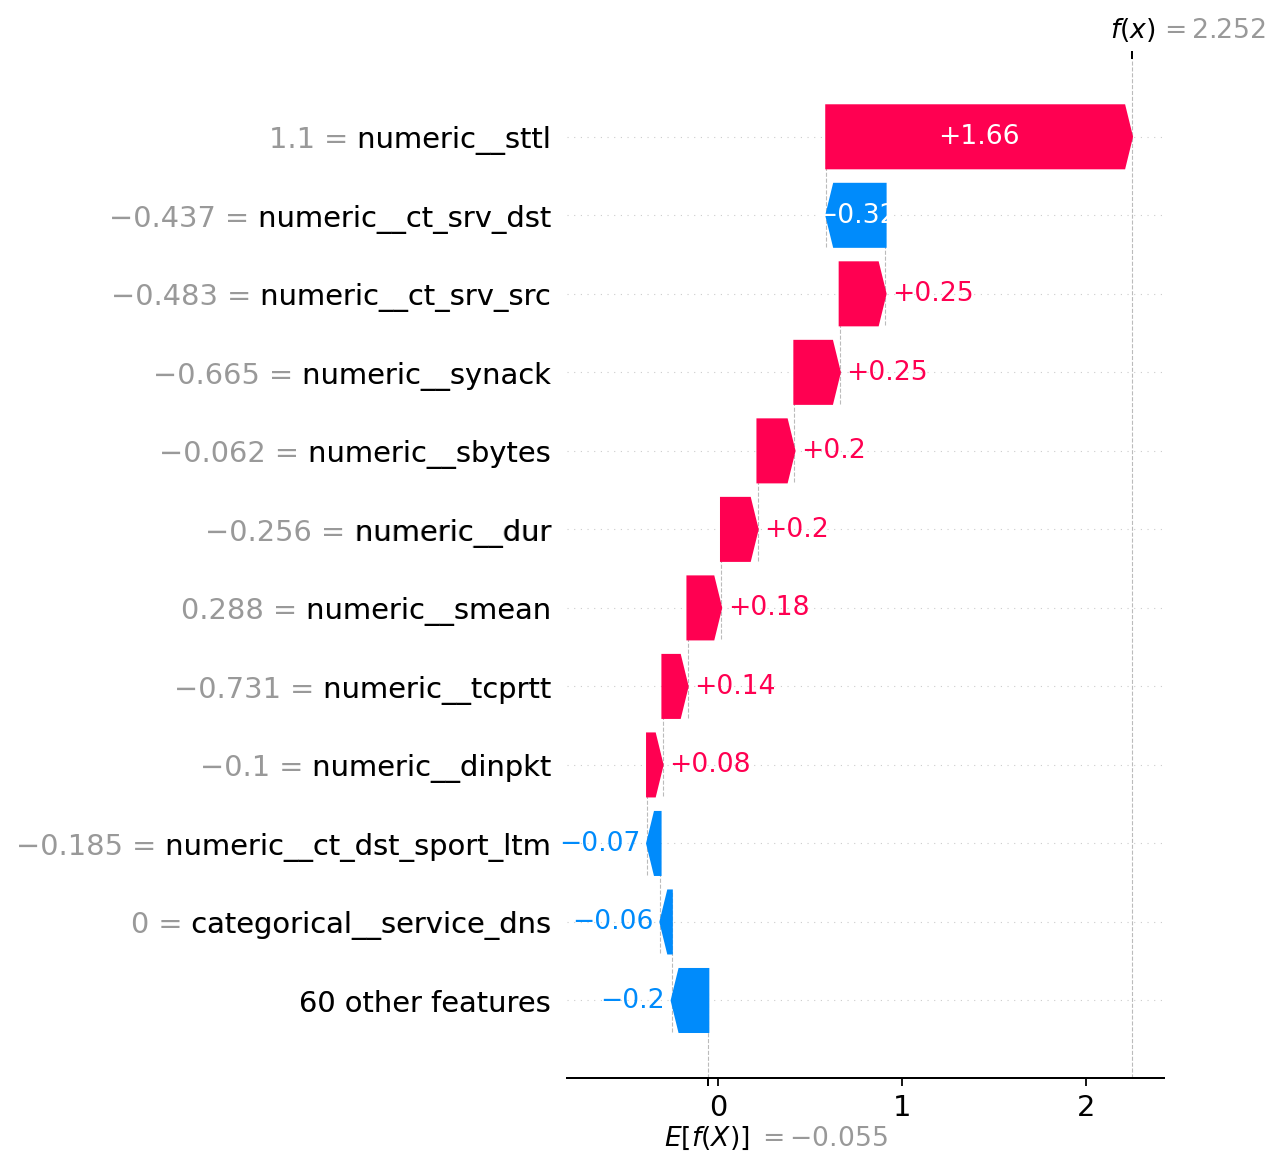

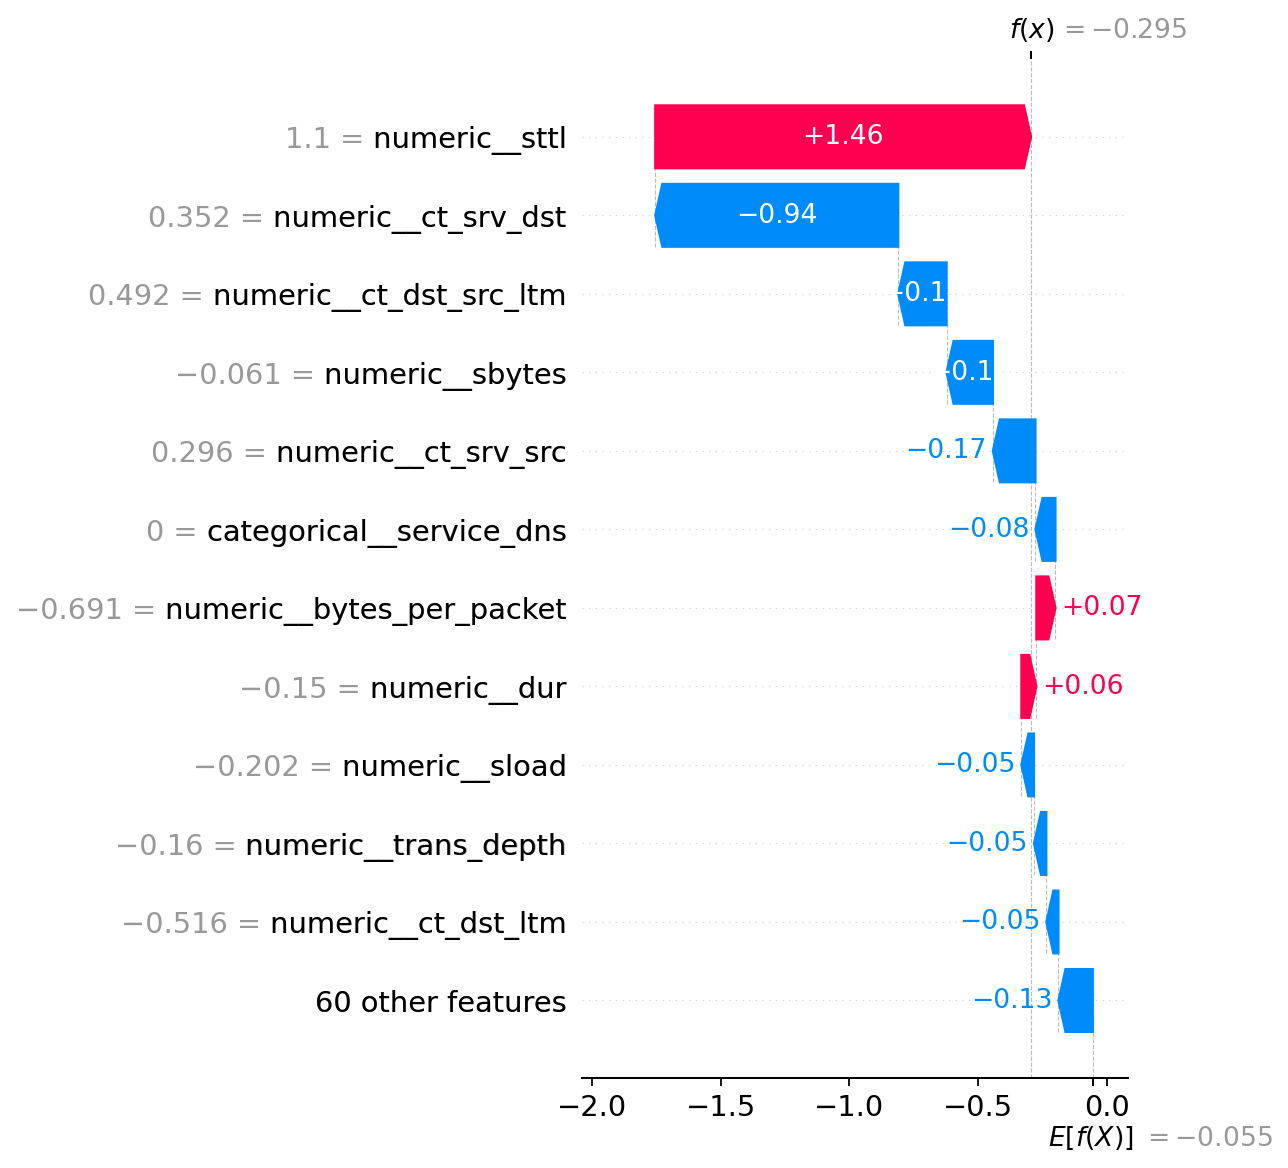

# Explainability

SHAP explains **XGBoost**, the best tree family by validation average precision. The selected deployment prototype model is XGBoost. Global plots use 160 deterministic random primary-test examples; local examples are the first available member of each prediction outcome. Local examples illustrate behavior and are not representative estimates.

## Global behavior
Largest mean absolute contributions: numeric__sttl, numeric__ct_state_ttl, numeric__ct_srv_dst, numeric__dbytes, numeric__ct_dst_src_ltm. `shap_beeswarm.png` shows direction and spread, while `shap_importance.png` shows magnitude. Positive contributions push toward attack and negative contributions toward benign, measured in **log odds** for this explainer. Contributions refer to transformed inputs; numeric colors therefore reflect standardized values, and one-hot colors indicate category activation. Magnitude alone gives no direction; inspect the beeswarm or local signs.

TTL, state and context-count features can reflect capture topology, device defaults or traffic-generator behavior. Dominance of these variables is a reason for transferability testing and feature ablation, not evidence that all high-TTL flows are malicious. `id`, `label` and `attack_cat` are explicitly absent from the model schema. Correlated features can share attribution, and SHAP is neither causal proof nor a security rule.

## Local explanations
### True Positive

Row 244, category Reconnaissance, attack score 0.9759. Strongest contributions: numeric__sttl (+1.874); numeric__ct_srv_dst (+0.871); numeric__ct_srv_src (+0.427); numeric__tcprtt (+0.390); numeric__synack (+0.273); numeric__smean (+0.157).

### True Negative

Row 35, category Normal, attack score 0.3755. Strongest contributions: numeric__sttl (+1.507); numeric__ct_srv_dst (-0.368); numeric__smean (-0.272); numeric__sbytes (-0.267); numeric__synack (-0.158); numeric__dmean (-0.140).

### False Positive

Row 1, category Normal, attack score 0.9048. Strongest contributions: numeric__sttl (+1.663); numeric__ct_srv_dst (-0.322); numeric__ct_srv_src (+0.249); numeric__synack (+0.247); numeric__sbytes (+0.201); numeric__dur (+0.198).

### False Negative

Row 278, category Fuzzers, attack score 0.4269. Strongest contributions: numeric__sttl (+1.459); numeric__ct_srv_dst (-0.944); numeric__ct_dst_src_ltm (-0.187); numeric__sbytes (-0.180); numeric__ct_srv_src (-0.166); categorical__service_dns (-0.078).

Unavailable outcome classes: []. No synthetic example is substituted for an unavailable error class. Waterfall plots are stored as `figures/shap_<outcome>.png`; complete signed contributions for the displayed leading features are in `shap_details.json`.


In [3]:
for outcome in ['true_positive','true_negative','false_positive','false_negative']:
    figure(f'shap_{outcome}.png')
report('Explainability_Report.md')

Interpretation: local cases are real observations selected by outcome, not fabricated demonstrations. They illustrate why scores moved but do not estimate how common each explanation is.

In [4]:
audit=pd.read_csv(ROOT/'reports/subgroup_audit.csv')
display(audit[audit.group_type=='attack_cat'])
assert audit.loc[(audit.group_type=='attack_cat') & (audit.group!='Normal'),'fpr'].isna().all()
report('Bias_Fairness_Analysis.md')

,group_type,group,n,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp,recall_ci_low,recall_ci_high
151,attack_cat,Analysis,294,0.942177,1.0,0.942177,0.970228,NaN,NaN,NaN,0.057823,0,0,17,277,0.909359,0.963588
152,attack_cat,Backdoor,70,1.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,0.000000,0,0,0,70,0.947975,1.000000
153,attack_cat,DoS,1186,0.994941,1.0,0.994941,0.997464,NaN,NaN,NaN,0.005059,0,0,6,1180,0.989007,0.997679
154,attack_cat,Exploits,7085,0.992661,1.0,0.992661,0.996317,NaN,NaN,NaN,0.007339,0,0,52,7033,0.990389,0.994398
155,attack_cat,Fuzzers,4335,0.895732,1.0,0.895732,0.944999,NaN,NaN,NaN,0.104268,0,0,452,3883,0.886282,0.904482
156,attack_cat,Generic,3381,0.999704,1.0,0.999704,0.999852,NaN,NaN,NaN,0.000296,0,0,1,3380,0.998326,0.999948
157,attack_cat,Normal,33755,0.743594,0.0,NaN,0.000000,NaN,NaN,0.256406,NaN,25100,8655,0,0,NaN,NaN
158,attack_cat,Reconnaissance,2224,0.999550,1.0,0.999550,0.999775,NaN,NaN,NaN,0.000450,0,0,1,2223,0.997457,0.999921
159,attack_cat,Shellcode,365,0.991781,1.0,0.991781,0.995873,NaN,NaN,NaN,0.008219,0,0,3,362,0.976117,0.997201
160,attack_cat,Worms,43,1.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,0.000000,0,0,0,43,0.917987,1.000000


# Operational performance and bias audit

## Scope: operational groups, not demographic fairness
This dataset supplies no protected demographic attributes. No race, gender, age or socioeconomic variables are invented or inferred. The analysis audits performance across observed protocol, service, state and attack category. It supports **no demographic fairness conclusion**.

## Attack-category coverage

| group          |    n |   recall |    fnr |   fn |   recall_ci_low |   recall_ci_high |
|:---------------|-----:|---------:|-------:|-----:|----------------:|-----------------:|
| Fuzzers        | 4335 |   0.8957 | 0.1043 |  452 |          0.8863 |           0.9045 |
| Analysis       |  294 |   0.9422 | 0.0578 |   17 |          0.9094 |           0.9636 |
| Shellcode      |  365 |   0.9918 | 0.0082 |    3 |          0.9761 |           0.9972 |
| Exploits       | 7085 |   0.9927 | 0.0073 |   52 |          0.9904 |           0.9944 |
| DoS            | 1186 |   0.9949 | 0.0051 |    6 |          0.9890 |           0.9977 |
| Reconnaissance | 2224 |   0.9996 | 0.0004 |    1 |          0.9975 |           0.9999 |
| Generic        | 3381 |   0.9997 | 0.0003 |    1 |          0.9983 |           0.9999 |
| Worms          |   43 |   1.0000 | 0.0000 |    0 |          0.9180 |           1.0000 |
| Backdoor       |   70 |   1.0000 | 0.0000 |    0 |          0.9480 |           1.0000 |

Recall intervals use the Wilson 95% formula and assume independent flows. Shared capture conditions may violate independence. Attack-only groups have no benign denominator, so FPR is undefined (NaN), and benign-only groups have undefined recall/FNR. Precision is also undefined if the model produces no positive predictions. These are deliberately not replaced with zero. Attack-only precision can be trivially 1 and is not a useful service-alert measure.

## Services generating false alerts

| group    |     n |   precision |   recall |      fpr |    fnr |   fp |
|:---------|------:|------------:|---------:|---------:|-------:|-----:|
| -        | 34118 |      0.5558 |   0.9486 |   0.2980 | 0.0514 | 7298 |
| http     |  7891 |      0.8010 |   0.9957 |   0.2747 | 0.0043 | 1027 |
| ftp      |  1291 |      0.6135 |   0.9647 |   0.4343 | 0.0353 |  327 |
| radius   |     6 |      0.6667 |   1.0000 |   1.0000 | 0.0000 |    2 |
| dns      |  5848 |      0.9997 |   1.0000 |   0.0003 | 0.0000 |    1 |
| ftp-data |  1177 |      1.0000 |   1.0000 |   0.0000 | 0.0000 |    0 |
| dhcp     |    13 |      1.0000 |   1.0000 | nan      | 0.0000 |    0 |
| irc      |     5 |      1.0000 |   1.0000 | nan      | 0.0000 |    0 |
| pop3     |   381 |      1.0000 |   1.0000 | nan      | 0.0000 |    0 |
| smtp     |  1759 |      1.0000 |   1.0000 |   0.0000 | 0.0000 |    0 |

`subgroup_audit.csv` includes all observed groups and sample counts, precision, recall, F1, FPR, FNR and confusion counts. Small samples demand caution; rank large service groups by total false alerts for workload and inspect rates for disproportionate error burden.

## Bias sources and mitigations
Collection-environment bias: controlled traffic can reward shortcuts tied to topology. Mitigation: independent networks, device diversity and feature ablation using development data.

Temporal bias and concept drift: historical attack behavior may not match current telemetry. Mitigation: time-separated validation, recent labeled data, monitoring of feature distributions and delayed-label recall, and versioned retraining.

Representation bias and imbalance: rare attack categories have little statistical support. Mitigation: collect additional authentic examples and report per-category recall with uncertainty. Weighting and threshold selection alone do not guarantee minority coverage.

Overfitting and leakage: exact duplicate removal, explicit predictor exclusions and training-only transforms reduce known pathways. Near-duplicates, shared sessions and aggregate fields with uncertain online availability remain concerns. Mitigation: group/time splits where provenance allows and a causal feature extractor.

Adversarial adaptation: actors can change behavior over time. Mitigation: combine the prototype with signature systems, endpoint telemetry and analyst review; assess defensive robustness using approved recorded datasets. This project does not implement attack generation.

False-positive fatigue: aggregate alerts by incident and asset context, set a measured workload budget, review service-specific errors and monitor calibration. Establish rollback and human approval before any response action.

## Governance and ethics
Network metadata can still be sensitive. Minimize retention and identifiers, restrict access to uploaded flows, keep the demo local, and avoid publishing operational telemetry. Document data terms, model version and decision threshold. Human researchers must validate methodology and claims, especially if the project is reused outside this academic setting.


Interpretation: group support and uncertainty matter. Attack-only groups have undefined FPR; no demographic protected attributes are available. Mitigations require new evaluation data and human governance.